In [ ]:
import warnings 
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from networkx.drawing.nx_agraph import graphviz_layout

warnings.filterwarnings('ignore')
%matplotlib inline
%load_ext autoreload
%autoreload 2

pd.options.display.float_format = "{:,.3f}".format
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

INFILE_MUTATIONS = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/manual/mutations.assigned.010426.tsv'
INFILE_SAMPLESHEET = '/home/grace/work/PPCG_DifferentialGenesetMutation/samplesheet.angel.alldonors.tsv'
INFILE_CLONEMETA = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/26.03.2026/metastatic_clones_with_ancestors.tsv'
INDIR_DPCLUST = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/26.03.2026/ccf/Clonal_trees'
INDIR_CONIPHER = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/06.03.2026/conipher_trees'

sheet = pd.read_csv(INFILE_SAMPLESHEET, sep='\t', header=0)
sheet['tissue'] = sheet['tissue'].replace('Recurrence', 'Metastasis')
SAMPLE_2_TISSUE = sheet.set_index('sample')['tissue'].to_dict()

In [93]:
def load_mutations(mutations_path: str) -> pd.DataFrame:
    df = pd.read_csv(mutations_path, sep='\t', header=0)
    df['clone'] = df['clone'].astype(str)
    mask = df['clone'].isna()
    df.loc[mask, 'clone'] = '.'
    df.loc[~mask, 'clone'] = df.loc[~mask, 'clone'].apply(lambda x: x.split('.')[0])
    df['method'] = df['method'].astype(str)
    df['donor'] = df['sample'].apply(lambda x: x[:8])
    return df 

def annotate_tissue_cohort(table: pd.DataFrame, samplesheet_path: str) -> pd.DataFrame:
    df = table.copy()
    sheet = pd.read_csv(samplesheet_path, sep='\t', header=0)
    sheet['tissue'] = sheet['tissue'].replace('Recurrence', 'Metastasis')
    donor2cohort = sheet.drop_duplicates('donor').set_index('donor')['cohort'].to_dict()
    sample2tissue = sheet.drop_duplicates('sample').set_index('sample')['tissue'].to_dict()
    df['cohort'] = df['donor'].map(donor2cohort)
    df['tissue'] = df['sample'].map(sample2tissue)
    assert df['cohort'].isna().sum() == 0
    assert df['tissue'].isna().sum() == 0
    return df 

df = load_mutations(INFILE_MUTATIONS)
df = annotate_tissue_cohort(df, INFILE_SAMPLESHEET)
df.head()
# print(df.dtypes)
# print()
# print(df.isna().sum()/df.shape[0]*100)
# print()
# print(df.groupby('cohort')['method'].value_counts(dropna=False))

,sample,coords,ref,alt,vclass,vtype,annotation,est_ccf,gene,clone,method,donor,cohort,tissue
0,PPCG0001a,7:121716013,T,G,SNV,SNV,3_prime_UTR_variant,0.870,AASS,.,NaN,PPCG0001,PPCG,Primary
1,PPCG0001a,7:121732980,T,G,SNV,SNV,missense_variant,0.760,AASS,.,NaN,PPCG0001,PPCG,Primary
2,PPCG0001a,20:25038761,C,G,SNV,SNV,5_prime_UTR_variant,0.880,ACSS1,.,NaN,PPCG0001,PPCG,Primary
3,PPCG0001a,2:206405989-2:207329092,.,.,SV,DUP,gene_fusion,NaN,ADAM23,.,NaN,PPCG0001,PPCG,Primary
4,PPCG0001a,10:76221633-10:115874382,.,.,SV,INV,transcript_ablation,NaN,ADK,.,NaN,PPCG0001,PPCG,Primary


In [114]:
def annotate_seeding_trajectory(table: pd.DataFrame, clonemeta_path: str) -> pd.DataFrame:
    df = table.copy()

    meta = pd.read_csv(clonemeta_path, sep='\t', header=0)
    meta['clone'] = meta['clone'].astype(str)
    target_donors = set(meta['patient'].unique())

    donor2clones = dict()
    for donor, donor_df in meta.groupby('patient'):
        # get clones considered on seeding trajectory
        path_clones = set()
        for traj in donor_df['ancestors'].values:
            nodelist = traj.split('-')
            nodelist = nodelist[:-1]
            assert len(nodelist) >= 1
            path_clones.update(nodelist)
        donor2clones[donor] = path_clones

    df['seeding_trajectory'] = False 
    for donor in target_donors:
        mask = (df['donor']==donor) & (df['clone'].isin(donor2clones[donor]))
        df.loc[mask, 'seeding_trajectory'] = True 
    
    return df.copy()

df = load_mutations(INFILE_MUTATIONS)
df = annotate_tissue_cohort(df, INFILE_SAMPLESHEET)
df = annotate_seeding_trajectory(df, INFILE_CLONEMETA)
df = df[df['cohort']=='COMBI'].copy()
print(df.groupby('seeding_trajectory')['donor'].nunique())
# cmap = df[df['seeding_trajectory']==True].groupby('donor')['clone'].agg(set)
# print(cmap.shape)
# print(cmap)
df[df['seeding_trajectory']==True].head(10)

seeding_trajectory
False    102
True      69
Name: donor, dtype: int64


,sample,coords,ref,alt,vclass,vtype,annotation,est_ccf,gene,clone,method,donor,cohort,tissue,seeding_trajectory
14904,PPCG0086a,13:95377101-13:95745320,.,.,SV,DUP,transcript_ablation,NaN,ABCC4,4,site-parsimony (exact),PPCG0086,COMBI,Metastasis,True
14905,PPCG0086a,chr10:27035522-27150016,.,1+0,CNA,CNA,LOH,0.990,ABI1,1,site-parsimony (exact),PPCG0086,COMBI,Metastasis,True
14906,PPCG0086a,3:131842350-3:132284558,.,.,SV,DUP,transcript_ablation,NaN,ACAD11,5,site-parsimony (exact),PPCG0086,COMBI,Metastasis,True
14907,PPCG0086a,19:5939647-19:6165257,.,.,SV,DUP,bidirectional_gene_fusion,NaN,ACSBG2,1,site-parsimony (exact),PPCG0086,COMBI,Metastasis,True
14908,PPCG0086a,1:18136004-6:45820352,.,.,SV,TRA,transcript_ablation,NaN,ACTL8,1,site-parsimony (exact),PPCG0086,COMBI,Metastasis,True
14909,PPCG0086a,1:18135396-6:45820354,.,.,SV,TRA,transcript_ablation,NaN,ACTL8,1,site-parsimony (exact),PPCG0086,COMBI,Metastasis,True
14910,PPCG0086a,1:18133689-X:26071645,.,.,SV,TRA,transcript_ablation,NaN,ACTL8,1,site-parsimony (exact),PPCG0086,COMBI,Metastasis,True
14911,PPCG0086a,1:18133696-X:26073844,.,.,SV,TRA,transcript_ablation,NaN,ACTL8,1,site-parsimony (exact),PPCG0086,COMBI,Metastasis,True
14912,PPCG0086a,1:18134822-X:26073369,.,.,SV,TRA,transcript_ablation,NaN,ACTL8,1,site-parsimony (exact),PPCG0086,COMBI,Metastasis,True
14913,PPCG0086a,1:18134919-X:26071802,.,.,SV,TRA,transcript_ablation,NaN,ACTL8,1,site-parsimony (exact),PPCG0086,COMBI,Metastasis,True


In [ ]:
meta = pd.read_csv(INFILE_CLONEMETA, sep='\t', header=0)
meta['clone'] = meta['clone'].astype(str)

# for donor, donor_df in meta.groupby('patient'):
#     tree_path = f"{INDIR_CONIPHER}/{donor}_conipher_tree/allTrees.txt"
#     ccfs_path = f"{INDIR_DPCLUST}/{donor}_Cluster_CCFs.csv"
#     ccfs = load_dpclust_ccfs(ccfs_path)
#     T = load_conipher_tree(tree_path, ccfs)
#     ccf_clones = set(ccfs.index.to_list())
#     tree_clones = set(T.nodes())
#     meta_clones = set(donor_df['clone'].unique())
#     path_clones = set()
#     for traj in donor_df['ancestors'].values:
#         nodelist = traj.split('-')
#         nodelist = nodelist[:-1]
#         assert len(nodelist) >= 1
#         path_clones.update(nodelist)

#     missing1 = meta_clones - tree_clones
#     missing2 = path_clones - tree_clones
#     assert tree_clones == ccf_clones
#     assert len(missing1) == 0
#     assert len(missing2) == 0

# meta[meta['patient']=='PPCG0179']
meta.head(15)

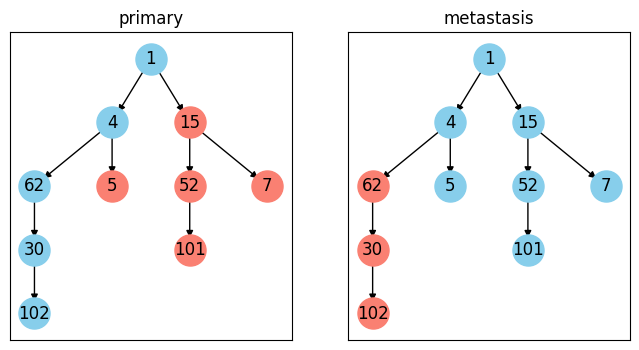

         PPCG0086a  PPCG0086c  PPCG0086d  PPCG0086e
Cluster                                            
1            0.990      1.000      1.000      1.000
4            0.970      0.000      0.000      1.000
5            0.960      0.000      0.000      0.000
7            0.000      0.330      0.000      0.000
101          0.000      0.000      0.280      0.000
102          0.000      0.000      0.000      0.110
15           0.000      0.970      1.000      0.000
30           0.000      0.000      0.000      0.350
52           0.000      0.000      0.950      0.000
62           0.000      0.000      0.000      0.850


In [105]:
def load_dpclust_ccfs(filepath: str, minccf: float=0.05) -> pd.DataFrame:
    df = pd.read_csv(filepath, sep=',', header=0)
    df['Cluster'] = df['Cluster'].apply(lambda x: str(x).replace('_', '').split('.')[0])
    df = df.set_index('Cluster')
    df.columns = [x.replace('_DNA', '') for x in df.columns]
    df = df[[x for x in df.columns if x.startswith('PPCG')]].copy()
    for col in df.columns:
        mask = df[col]<minccf
        df.loc[mask, col] = 0.00
    df = df.clip(lower=0, upper=1)
    return df.copy()

def load_conipher_tree(filepath: str, ccfs: pd.DataFrame) -> nx.DiGraph:
    patient = ccfs.columns.to_list()[0][:8]
    T = _load_tree1(filepath)

    # hacky hot-fix for PPCG0435 where clone 11 was merged into clone 4 (trunk)
    if patient == 'PPCG0435':
        T.remove_node('11')
        
    T = _annotate_samples(T, ccfs)
    return T

def _annotate_samples(T: nx.DiGraph, ccfs: pd.DataFrame) -> nx.DiGraph:
    df = ccfs.T.copy()
    for node in T.nodes():
        present = df[df[node]>0].index.to_list()
        T.nodes[node]['samples'] = set(present)
    return T

def _load_tree1(filepath: str) -> nx.DiGraph:

    trees = {}
    
    with open(filepath, 'r') as fp:
        line = fp.readline().strip()
        line = fp.readline().strip()
        assert line == '# tree 1'

        name = line.strip('# ')
        T = nx.DiGraph()
        line = fp.readline().strip()
        while line:
            if line.startswith('#'):
                trees[name] = T
                name = line.strip('# ')
                T = nx.DiGraph()
            else:
                parent, child = line.split('\t')
                parent = parent.replace('_', '')
                child = child.replace('_', '')
                T.add_edge(parent, child)
            line = fp.readline().strip()
        trees[name] = T
    
    return trees['tree 1']

def draw_tree_primet(T: nx.DiGraph, ccfs: pd.DataFrame) -> None:
    primary_samples = [x for x in ccfs.columns.to_list() if SAMPLE_2_TISSUE[x]=='Primary']
    secondary_samples = [x for x in ccfs.columns.to_list() if SAMPLE_2_TISSUE[x]=='Metastasis']
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
    labels = ['primary', 'metastasis']
    sgroups = [primary_samples, secondary_samples]
    for i, (label, samples) in enumerate(zip(labels, sgroups)):
        present = set()
        for s in samples:
            present.update(ccfs[ccfs[s]>0].index.to_list())
        ax = axes[i]
        pos = graphviz_layout(T, prog='dot')
        nl_present = [n for n in T.nodes() if n in present]
        nl_missing = [n for n in T.nodes() if n not in present]
        nx.draw_networkx_nodes(T, pos, nodelist=nl_present, node_color='skyblue', node_size=500, ax=ax)
        nx.draw_networkx_nodes(T, pos, nodelist=nl_missing, node_color='salmon', node_size=500, ax=ax)
        nx.draw_networkx_labels(T, pos, ax=ax)
        nx.draw_networkx_edges(T, pos, ax=ax)
        ax.set_title(label)
        i += 1
    plt.show()
    plt.close()

DONOR = 'PPCG0086'
tree_path = f"{INDIR_CONIPHER}/{DONOR}_conipher_tree/allTrees.txt"
ccfs_path = f"{INDIR_DPCLUST}/{DONOR}_Cluster_CCFs.csv"
ccfs = load_dpclust_ccfs(ccfs_path)
T = load_conipher_tree(tree_path, ccfs)
draw_tree_primet(T, ccfs)
print(ccfs)

In [ ]:
meta = pd.read_csv(INFILE_CLONEMETA, sep='\t', header=0)
meta['clone'] = meta['clone'].astype(str)
meta[meta['patient']=='PPCG0086']